## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

### Q1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, classification_report

In [3]:
golub = pd.read_csv('/Users/clairicelou/Documents/DS3021/undergrad_ml_assignments/data/golub.csv', encoding='latin1')

golub.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [4]:
golub['cancer'].unique()

<ArrowStringArray>
['allB', 'allT', 'aml']
Length: 3, dtype: str

In [5]:
golub['cancer'] = golub['cancer'].replace({
    'allB': 0,
    'allT': 0,
    'aml': 1
})

In [6]:
golub = golub[golub['cancer'].isin([0, 1])]

### Q2

In [7]:
y = golub['cancer']
X = golub.drop(columns=['Samples','BM.PB','Gender','Source','tissue.mf','cancer'])

model = LinearRegression()
model.fit(X, y)
y_hat = model.predict(X)

mse = np.mean((y - y_hat)**2)
print(f"Mean Squared Error: {mse}")

residuals = y - y_hat

Mean Squared Error: 3.5610016687287904e-30


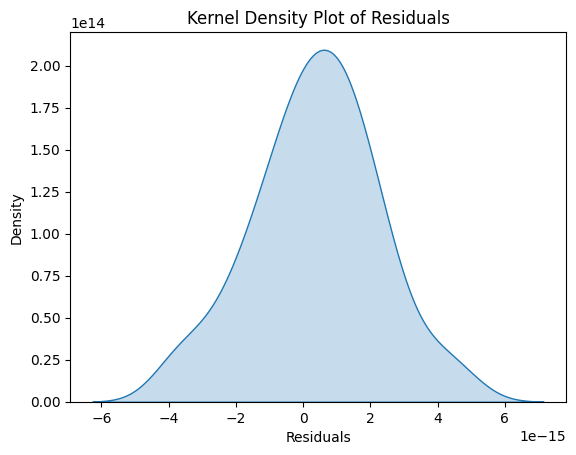

In [8]:
sns.kdeplot(residuals, fill=True)
plt.title("Kernel Density Plot of Residuals")
plt.xlabel("Residuals")
plt.show()

Text(0.5, 1.0, 'Predicted vs Actual')

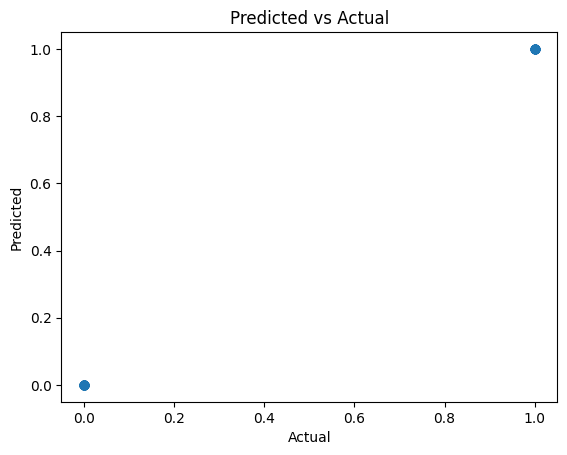

In [9]:
plt.scatter(y, y_hat)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

### Q3

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

model = LinearRegression()

cv_mse = -cross_val_score(model, X, y, cv=10, scoring='neg_mean_squared_error')

print(f"Cross-validated MSE: {cv_mse.mean()}")

Cross-validated MSE: 0.06780005217137444


The cross validated MSE is about 0.0678. Since cross validation evaluates the model on unseen data this basically shows how well the model generalizes. Because the model uses a very large number of gene features corresponding to the number of observations, it is very complex and likely has low bias but high variance. This means that it may fit the training data well but perform worse on new data. This is an example of the bias variance tradeoff where increasing model complexity decreases bias but increases variance and can hurt overall performance.

### Q4

In [13]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=10, random_state=100, max_iter=10000)
lasso.fit(X_scaled, y)

y_hat = lasso.predict(X_scaled)

In [14]:
coefs = lasso.coef_

selected_genes = X.columns[coefs != 0]

print("Selected genes:")
print(selected_genes)

print("Number of selected genes:", len(selected_genes))

Selected genes:
Index(['AF000560_at', 'AF006087_at', 'D26579_at', 'D29956_at', 'D42043_at',
       'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at', 'J04164_at',
       'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at',
       'M27819_at', 'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at',
       'M63138_at', 'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at',
       'U10868_at', 'U14588_at', 'U30828_at', 'U34877_at', 'U36621_cds2_at',
       'U46751_at', 'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at',
       'U82759_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at',
       'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at', 'X69111_at',
       'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at', 'Y07604_at',
       'Y07755_at', 'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at',
       'AC002477_s_at', 'L15326_s_at', 'X57351_at', 'U37055_rna1_s_at',
       'X07438_s_at', 'M13690_s_at', 'M26708_s_at', 'M84371_rna1_s_at',
       'X12876_s_

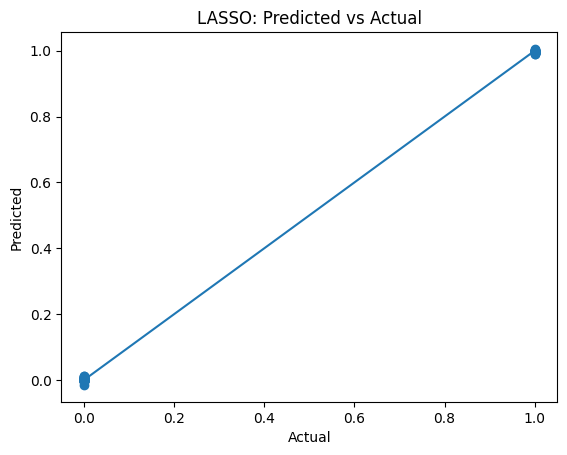

In [15]:
plt.scatter(y, y_hat)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LASSO: Predicted vs Actual")

plt.plot([0,1], [0,1]) 
plt.show()

In [17]:
X.shape[1]

7129

Which set of genes is selected?

The LASSO selects the genes with nonzero coefficients. The selected genes:

AF000560_at, AF006087_at, D26579_at, D29956_at, D42043_at, D50840_at, D86982_at, HG2161-HT2231_at, J04101_at, J04164_at, M17754_at, M19507_at, M20902_at, M22960_at, M23197_at, M27819_at, M27891_at, M28713_at, M31994_at, M34344_at, M63138_at, M84526_at, M95178_at, M96326_rna1_at, M98539_at, U10868_at, U14588_at, U30828_at, U34877_at, U36621_cds2_at, U46751_at, U50136_rna1_at, U51127_at, U60062_at, U82313_at, U82759_at, U89942_at, X04143_at, X14789_at, X16706_at, X56741_at, X63753_at, X66533_at, X66867_cds1_at, X69111_at, X81479_at, X83378_at, X95735_at, X96698_at, Y07604_at, Y07755_at, Y10207_at, Y12670_at, M96843_at, X58072_at, AC002477_s_at, L15326_s_at, X57351_at, U37055_rna1_s_at, X07438_s_at, M13690_s_at, M26708_s_at, M84371_rna1_s_at, X12876_s_at, U26312_s_at, X85116_rna1_s_at, HG4518-HT4921_r_at, L08010_at, U84388_at, X06318_at.

These are the genes that stay in the model after applying the LASSO penalty.

How many genes are discarded?

Discarded ≈ 7129 − 70 = 7059 genes

The LASSO selects 70 genes and shrinks all other coefficients to zero. Since the dataset contains about 7000 genes, this means that over 7000 genes are discarded from the model.

### Q5

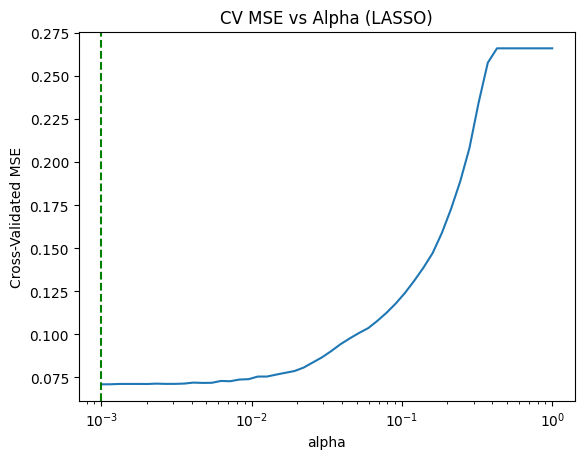

Optimal alpha: 0.001


In [18]:
from sklearn.linear_model import LassoCV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

alpha_grid = np.logspace(-3, 0, 50)

lasso = LassoCV(cv=10, alphas=alpha_grid,random_state=100,max_iter=10000)

lasso.fit(X_scaled, y)

mean_mse = np.mean(lasso.mse_path_, axis=1)

alpha_star = lasso.alpha_

sns.lineplot(x=lasso.alphas_, y=mean_mse)
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE vs Alpha (LASSO)")
plt.show()

print(f"Optimal alpha: {alpha_star}")

1. Where is the model underfitting?

The model is underfitting when alphha is large (around a > 0.001). As a increases, the LASSO penalty gets stronger, which pushes a lot of the coefficients closer to zero. This makes the model too simple so it can’t really capture the patterns in the data anymore. You can see this in the graph because the cross validated MSE increases a lot on the right side.

2. Where is the model overfitting?
   
The model is overfitting when a is very small (less than 0.001). When a is close to zero, the penalty is basically not doing much, so the model behaves like regular linear regression. It tries to fit all the data points including noise which makes it too complex and not as good at predicting new data.

3. What is the optimal penalty?

The optimal value is a = 0.001. This is where the cross validated MSE is lowest (the dashed green line). It’s kind of the best balance between underfitting and overfitting, where the model is flexible enough to capture patterns but not so complex that it fits noise.

### Q6

Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

Linear regression performs almost perfectly on the training set because it uses a large number of gene variables, giving it a lot of flexibility since it can closely fit the training data, very low bias, and very low training error. However, this leads to overfitting and high variance, so it does not generalize well. The LASSO adds a penalty that shrinks many coefficients to 0, reducing the number of variables in the model. This increase bias a little bit but greatly reduces variance, leading to better predictions overall.

### Q7

Why do regularization methods lend themselves to scenarios like precision health?

Regularization methods work well in precision health because the data usually has many more variables (like genes) than observations. This can cause overfitting. Regularization reduces model complexity by shrinking coefficients, which lowers variance and improves predictions. Methods like LASSO also select the most important variables, making the model more interpretable and useful for identifying key genes.

### Q8

What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

Some risks of applying methods like the LASSO in precision health is that they focus on prediction, not what actually causes outcomes. The model may pick genes that are related to the outcome but not actually causing them. If interventions are based on these results, they may be ineffective or even harmful. Additionally, LASSO can be unstable in high dimensional settings, meaning that small changes in the data could lead to different genes being selected which reduce reliability.